<a href="https://colab.research.google.com/github/ann-chill/global-passport-mobility-index/blob/main/GLOBAL_MOBILITY_INDEX.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#### Author: Ann-Shirley Coomson
#### Date: 10th March 2026

#### Title: Global Passport Modbility Index
#### Introduction: This project explores access to visa-free destinations per country.

#### Data Loading

In [8]:
import pandas as pd

df = pd.read_csv("HPI_2026.csv")

df.head()

,Origin,Destination,Requirement
0,Afghanistan,Afghanistan,NaN
1,Afghanistan,Albania,Visa Required
2,Afghanistan,Algeria,Visa Required
3,Afghanistan,American Samoa,Visa Required
4,Afghanistan,Andorra,Visa Required


In [9]:
len(df)

45173

In [10]:
df['Requirement'].value_counts()

,count
Requirement,
Visa Required,23538
Visa Free,21439


#### Data Cleaning

In [11]:
df.isnull().sum()

,0
Origin,0
Destination,0
Requirement,196


In [13]:
df = df.dropna()

In [7]:
len(df)

44977

In [16]:
df.shape

(44977, 3)

In [18]:
df.count()

,0
Origin,44977
Destination,44977
Requirement,44977


#### Passport Mobility Index

In [20]:
visa_free = df[df["Requirement"] == "Visa Free"]

mobility_score = visa_free.groupby("Origin")["Destination"].count()

mobility_score = mobility_score.reset_index()
mobility_score.columns = ["Country", "Visa_Free_Count"]

mobility_score.head()

,Country,Visa_Free_Count
0,Afghanistan,24
1,Albania,120
2,Algeria,55
3,Andorra,170
4,Angola,48


#### Global Mobility Map

In [61]:
import pandas as pd
import plotly.express as px

fig = px.choropleth(
    mobility_score,
    locations="Country",
    locationmode="country names",
    color="Visa_Free_Count", # Changed from 'Visa_Free_Destinations' to 'Visa_Free_Count'
    color_continuous_scale="Viridis",
    title="Global Passport Mobility Index (Visa-Free Travel Access)" # Correct way to set title in Plotly Express
)

fig.show()

#### Strongest Vs Weakest Passports

In [44]:
import pandas as pd

df = pd.read_csv("HPI_2026.csv")

visa_free = df[df["Requirement"] == "Visa Free"]

passport_scores = (
    visa_free.groupby("Origin")["Destination"]
    .nunique()
    .reset_index()
)

passport_scores.columns = ["Passport", "Visa_Free_Count"]

passport_scores.head()

,Passport,Visa_Free_Count
0,Afghanistan,24
1,Albania,120
2,Algeria,55
3,Andorra,170
4,Angola,48


In [54]:
top10 = passport_scores.sort_values(
    by="Visa_Free_Count",
    ascending=False
).head(10)

print(top10)

                 Passport  Visa_Free_Count
153             Singapore              192
83                  Japan              187
159           South Korea              187
186  United Arab Emirates              186
168                Sweden              186
59                 France              185
62                Germany              185
99             Luxembourg              185
81                  Italy              185
79                Ireland              185


In [55]:
bottom10 = passport_scores.sort_values(
    by="Visa_Free_Count",
    ascending=True
).head(10)

print(bottom10)

        Passport  Visa_Free_Count
0    Afghanistan               24
170        Syria               26
78          Iraq               29
195        Yemen               31
131     Pakistan               32
157      Somalia               33
121        Nepal               35
127  North Korea               36
13    Bangladesh               37
54       Eritrea               38


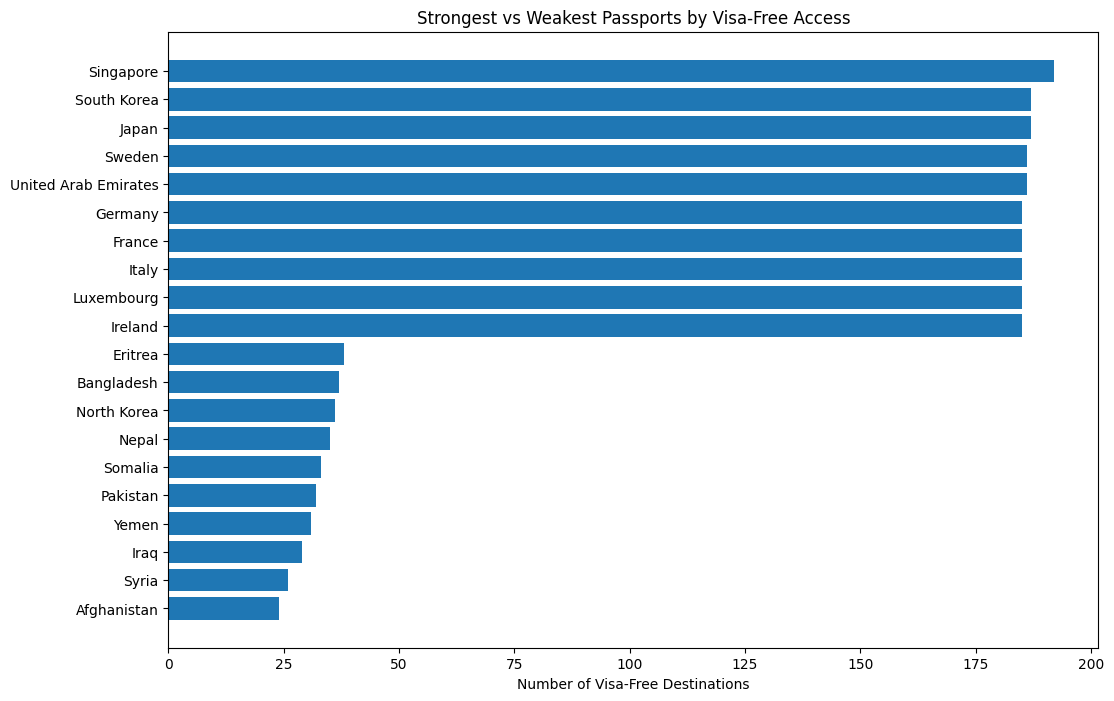

In [56]:
combined = pd.concat([top10, bottom10])

combined_sorted = combined.sort_values("Visa_Free_Count")

plt.figure(figsize=(12,8))

plt.barh(
    combined_sorted["Passport"],
    combined_sorted["Visa_Free_Count"]
)

plt.title("Strongest vs Weakest Passports by Visa-Free Access")
plt.xlabel("Number of Visa-Free Destinations")

plt.show()

In [57]:
# Find strongest passport
strongest = passport_scores.loc[
    passport_scores["Visa_Free_Count"].idxmax()
]

# Find weakest passport
weakest = passport_scores.loc[
    passport_scores["Visa_Free_Count"].idxmin()
]

print("Strongest passport:")
print(strongest)

print("\nWeakest passport:")
print(weakest)

Strongest passport:
Passport           Singapore
Visa_Free_Count          192
Name: 153, dtype: object

Weakest passport:
Passport           Afghanistan
Visa_Free_Count             24
Name: 0, dtype: object


#### Key insight

In [58]:
difference = strongest["Visa_Free_Count"] - weakest["Visa_Free_Count"]

print("\nDifference in visa-free access:", difference)


Difference in visa-free access: 168


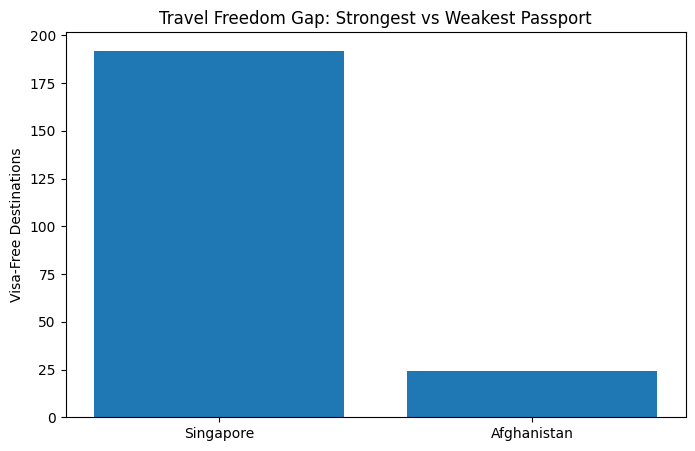

In [59]:
import matplotlib.pyplot as plt

countries = [strongest["Passport"], weakest["Passport"]]
values = [strongest["Visa_Free_Count"], weakest["Visa_Free_Count"]]

plt.figure(figsize=(8,5))

plt.bar(countries, values)

plt.title("Travel Freedom Gap: Strongest vs Weakest Passport")
plt.ylabel("Visa-Free Destinations")

plt.show()